# Image Classification with CNNs
**Objective:**

Build and compare different CNN models for image classification.

**We will:**

- Build a CNN from scratch
- Improve it with Batch Normalization and Dropout
- Use Data Augmentation
- Apply Transfer Learning
- Compare all models

## Step 1 — Import Libraries

In [1]:

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models
import matplotlib.pyplot as plt

2026-07-21 01:08:51.500484: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 01:08:53.491803: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784621334.357357    2540 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784621334.624394    2540 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784621336.188715    2540 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Step 2 — Load Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(x_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 1)


## Step 3 — Normalize Images

In [3]:
# Save raw copies for transfer learning
x_train_raw = x_train.copy()
x_test_raw = x_test.copy()

x_train = x_train / 255.0
x_test = x_test / 255.0

## Step 4 — Visualize Samples

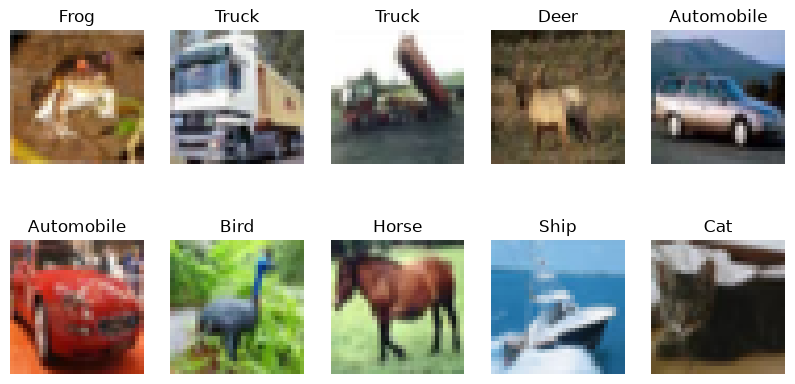

In [4]:
class_names = [
    "Airplane","Automobile","Bird","Cat","Deer",
    "Dog","Frog","Horse","Ship","Truck"
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

## Step 5 — CNN From Scratch

In [5]:
model = models.Sequential([

    layers.Input(shape=(32,32,3)),

    layers.Conv2D(32,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation="relu"),

    layers.Dense(10,activation="softmax")
])

model.summary()

I0000 00:00:1784615368.051544     489 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1414 MB memory:  -> device: 0, name: NVIDIA GeForce MX330, pci bus id: 0000:01:00.0, compute capability: 6.1


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6 — Compile

In [6]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

## Step 7 — Train

In [7]:
history = model.fit(

    x_train,
    y_train,

    epochs=30,

    validation_split=0.2

)

Epoch 1/30


I0000 00:00:1784615385.318922     540 service.cc:152] XLA service 0x727ad000abb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784615385.323983     540 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce MX330, Compute Capability 6.1
2026-07-20 23:29:45.560766: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784615386.023990     540 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-07-20 23:29:47.610564: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.6 = (f32[32,32,30,30]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,32,32]{3,2,1,0} %bitcast.1922, f32[32,3,3,3]{3,2,1,0} %bitcast.1929, f32[32]{0} %bitcast.2380), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivat

  24/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.1250 - loss: 2.2807

I0000 00:00:1784615390.459343     540 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1245/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4707 - loss: 1.4734

2026-07-20 23:30:00.317875: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.6 = (f32[32,32,30,30]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,32,32]{3,2,1,0} %bitcast.513, f32[32,3,3,3]{3,2,1,0} %bitcast.520, f32[32]{0} %bitcast.522), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/conv2d_1/convolution" source_file="/home/farhad/miniconda3/envs/tf219/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2026-07-20 23:30:00.326488: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially bu

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.4711 - loss: 1.4723 - val_accuracy: 0.5605 - val_loss: 1.2397
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6117 - loss: 1.1080 - val_accuracy: 0.6151 - val_loss: 1.1055
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6660 - loss: 0.9592 - val_accuracy: 0.6513 - val_loss: 0.9914
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7031 - loss: 0.8469 - val_accuracy: 0.6690 - val_loss: 0.9581
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7302 - loss: 0.7660 - val_accuracy: 0.6795 - val_loss: 0.9235
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7623 - loss: 0.6811 - val_accuracy: 0.6835 - val_loss: 0.9099
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7883 - loss: 0.6058 - val_accuracy: 0.6823 - val_loss: 0.9698
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8115 - loss: 0.5408 - val_accu

## Step 8 — Evaluate

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print(test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6554 - loss: 2.8775
0.6553999781608582


## Step 9 — Plot Accuracy

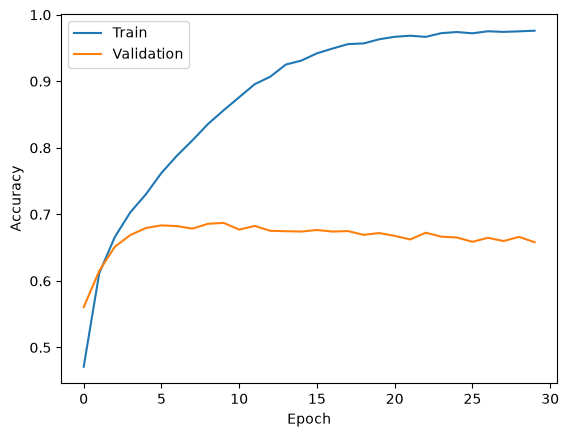

In [9]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

## Step 10 — Improve with Batch Normalization, Data Augmentation and Dropout

In [10]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1)

])

In [11]:
improved_model = models.Sequential([

    layers.Input(shape=(32,32,3)),
    data_augmentation,

    layers.Conv2D(32,(3,3),activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(10,activation="softmax")
])

improved_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,106 (1.21 MB)

 Trainable params: 315,914 (1.21 MB)

 Non-trainable params: 192 (768.00 B)

In [12]:
improved_model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [13]:
history = improved_model.fit(

    x_train,
    y_train,

    epochs=30,

    validation_split=0.2

)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.3378 - loss: 1.8458 - val_accuracy: 0.3813 - val_loss: 1.7674
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.4263 - loss: 1.5877 - val_accuracy: 0.4558 - val_loss: 1.5351
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.4688 - loss: 1.4897 - val_accuracy: 0.4431 - val_loss: 1.6259
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.4955 - loss: 1.4182 - val_accuracy: 0.5707 - val_loss: 1.2163
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.5190 - loss: 1.3670 - val_accuracy: 0.5568 - val_loss: 1.2790
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.5331 - loss: 1.3276 - val_accuracy: 0.5749 - val_loss: 1.2192
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.5463 - loss: 1.2911 - val_accuracy: 0.5640 - val_loss: 1.2302
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.5591 -

In [16]:
test_loss, test_acc = improved_model.evaluate(x_test, y_test)

print(test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7046 - loss: 0.8561
0.7045999765396118


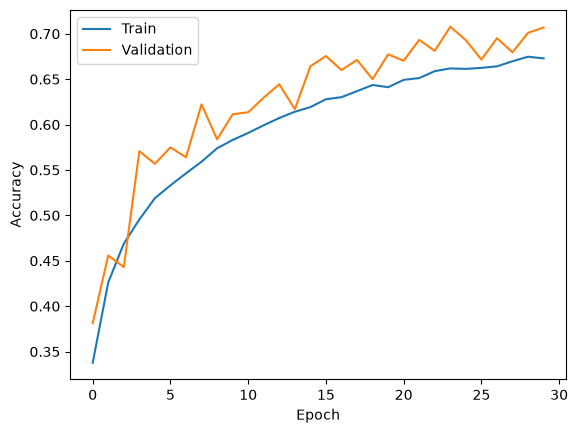

In [18]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

## Step 12 — Transfer Learning

### Load MobileNetV2

In [4]:
base_model = tf.keras.applications.MobileNetV2(

    input_shape=(96,96,3),

    include_top=False,

    weights="imagenet"

)

I0000 00:00:1784621408.062585    2540 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1414 MB memory:  -> device: 0, name: NVIDIA GeForce MX330, pci bus id: 0000:01:00.0, compute capability: 6.1


In [5]:
# Freeze Weights
base_model.trainable = False

### Resize Images

In [6]:
resize = layers.Resizing(96,96)

### Build Transfer Learning Model

In [7]:
model = models.Sequential([

    layers.Input(shape=(32,32,3)),

    resize,

    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.2),

    layers.Dense(10,activation="softmax")

])

**Compile:**

In [10]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

**Train:**

In [11]:
history = model.fit(

    x_train_raw,
    y_train,

    validation_split=0.2,

    epochs=10

)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 54s 38ms/step - accuracy: 0.8498 - loss: 0.4479 - val_accuracy: 0.8489 - val_loss: 0.4373
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.8571 - loss: 0.4217 - val_accuracy: 0.8589 - val_loss: 0.4169
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.8594 - loss: 0.4141 - val_accuracy: 0.8597 - val_loss: 0.4407
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.8600 - loss: 0.4135 - val_accuracy: 0.8624 - val_loss: 0.4058
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 38ms/step - accuracy: 0.8609 - loss: 0.4093 - val_accuracy: 0.8521 - val_loss: 0.4331
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.8605 - loss: 0.4102 - val_accuracy: 0.8606 - val_loss: 0.4285
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - accuracy: 0.8624 - loss: 0.4092 - val_accuracy: 0.8567 - val_loss: 0.4268
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - accuracy: 0.8647 -

**Evaluate:**

In [12]:
test_loss, test_acc = model.evaluate(x_test_raw, y_test)

print(f"Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8534 - loss: 0.4401
Test Accuracy: 0.8534


**Plot Accuracy:**

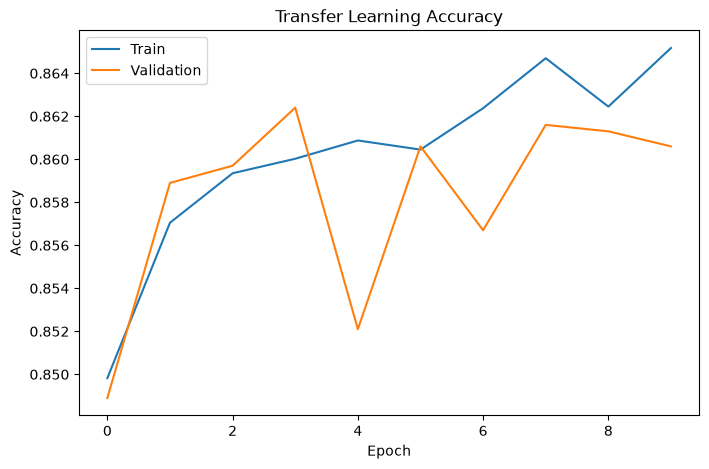

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Transfer Learning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

**Plot Loss:**

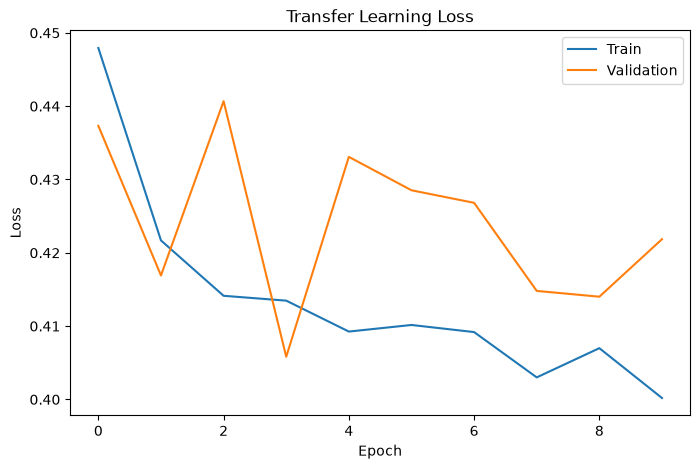

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.title("Transfer Learning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Fine-Tuning

In [15]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [16]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(1e-5),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [18]:
history = model.fit(

    x_train_raw,
    y_train,

    validation_split=0.2,

    epochs=10

)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 60s 48ms/step - accuracy: 0.7729 - loss: 0.8826 - val_accuracy: 0.8591 - val_loss: 0.5075
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 59s 47ms/step - accuracy: 0.8307 - loss: 0.5913 - val_accuracy: 0.8605 - val_loss: 0.4873
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - accuracy: 0.8521 - loss: 0.4904 - val_accuracy: 0.8626 - val_loss: 0.4582
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 50ms/step - accuracy: 0.8690 - loss: 0.4097 - val_accuracy: 0.8696 - val_loss: 0.4371
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 64s 51ms/step - accuracy: 0.8809 - loss: 0.3625 - val_accuracy: 0.8727 - val_loss: 0.4179
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 63s 50ms/step - accuracy: 0.8914 - loss: 0.3222 - val_accuracy: 0.8763 - val_loss: 0.4091
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - accuracy: 0.9030 - loss: 0.2845 - val_accuracy: 0.8821 - val_loss: 0.3937
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 65s 52ms/step - accuracy: 0.9100 -

In [19]:
test_loss, test_acc = model.evaluate(x_test_raw, y_test)

print(f"Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.8841 - loss: 0.3963
Test Accuracy: 0.8841


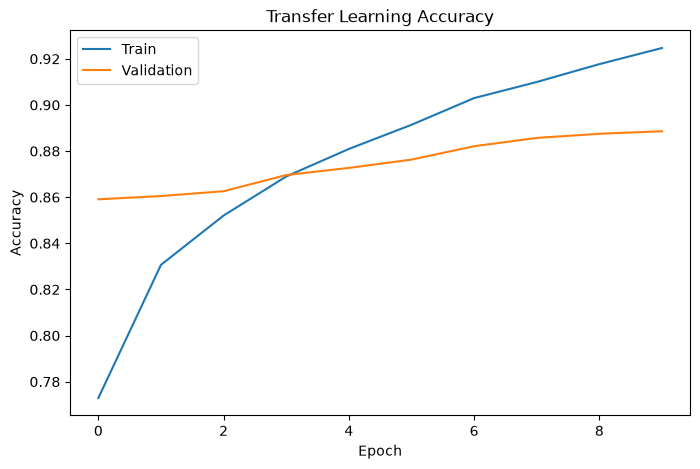

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Transfer Learning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

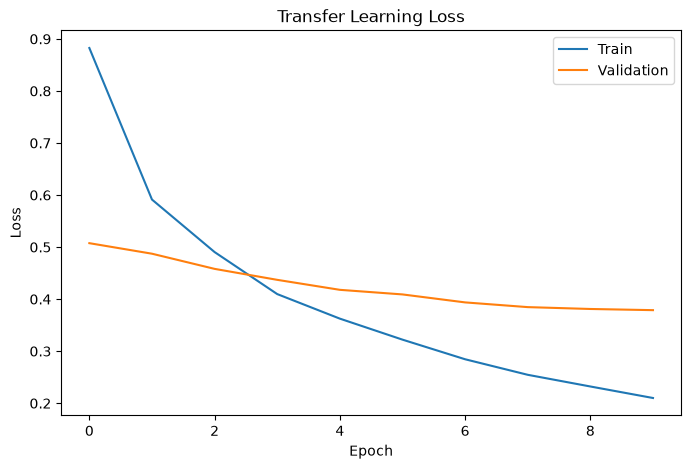

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.title("Transfer Learning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Transfer Learning Note

> **Note:** During the initial implementation of transfer learning, the model achieved only around **10–15% accuracy**, which is close to random guessing for a 10-class classification problem.
>
> After debugging, the issue was identified as an **input preprocessing mismatch**. The images had already been normalized to the range **[0, 1]**, while `tf.keras.applications.mobilenet_v2.preprocess_input` expects **raw pixel values in the range [0, 255]**. Since `preprocess_input` performs its own normalization to the range **[-1, 1]**, applying it to already normalized images resulted in incorrect input distributions for the pretrained MobileNetV2 model.
>
> The issue was resolved by preserving a copy of the original (unnormalized) dataset specifically for transfer learning, while continuing to use the normalized dataset for the CNN built from scratch. After this correction, the transfer learning model achieved significantly higher performance, demonstrating the importance of using the preprocessing pipeline expected by pretrained models.

## Final Model Comparison

# Model Performance Comparison

The table below summarizes the performance of all models trained throughout this project.

| Model | Training Accuracy | Validation Accuracy | Test Accuracy |
|:------|------------------:|--------------------:|--------------:|
| Baseline CNN | **97.6%** | **66.0%** | **65.5%** |
| CNN + Batch Normalization + Dropout + Data Augmentation | **67.0%** | **70.7%** | **70.5%** |
| MobileNetV2 (Frozen) | **86.5%** | **86.1%** | **85.3%** |
| MobileNetV2 (Fine-Tuned) | **92.5%** | **88.9%** | **88.4%** |

## Key Observations

- The **baseline CNN** achieved very high training accuracy but significantly lower validation and test accuracy, indicating **overfitting**.
- Adding **Batch Normalization, Dropout, and Data Augmentation** improved the model's ability to generalize, resulting in better validation and test performance despite lower training accuracy.
- **Transfer Learning** with a frozen MobileNetV2 backbone substantially outperformed the custom CNN, highlighting the effectiveness of pretrained feature extractors.
- **Fine-tuning** the top layers of MobileNetV2 further improved performance, achieving the highest validation and test accuracy among all models.

Overall, transfer learning combined with fine-tuning produced the best-performing model for the CIFAR-10 image classification task.